## Dataset Overview

This dataset is used for predicting the bankruptcy of Polish companies based on financial indicators and ratios. Bankrupt companies were analyzed during the period **2000–2012**, while companies that remained operational were evaluated from **2007–2013**.

The dataset contains multiple forecasting scenarios and a collection of financial features that can be used to build and evaluate bankruptcy prediction models.

For additional details about the dataset structure, forecasting periods, feature definitions, and target variable, refer to the **`dataset_description.md`** and **`data_dictionary.md`** files located in the **`references/`** directory.


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [40]:
df = pd.read_csv("../data/raw/Bankruptcy Master Dataset.csv",low_memory=False, index_col="id", dtype="float", na_values="?")
df[["Class","Year"]]=df[["Class","Year"]].astype("int")
df.index=df.index.astype("int")
df = df.reset_index(drop=True)
df.head()

,Year,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X56,X57,X58,X59,X60,X61,X62,X63,X64,Class
0,1,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0
1,1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,...,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0
2,1,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,...,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0
3,1,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0
4,1,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0


In [41]:
# Checking the distribution of tyhe positive and negative classes
df["Class"].value_counts(normalize=True)

Class
0    0.951826
1    0.048174
Name: proportion, dtype: float64

### keep in mindc the the feature `class` is our target variable

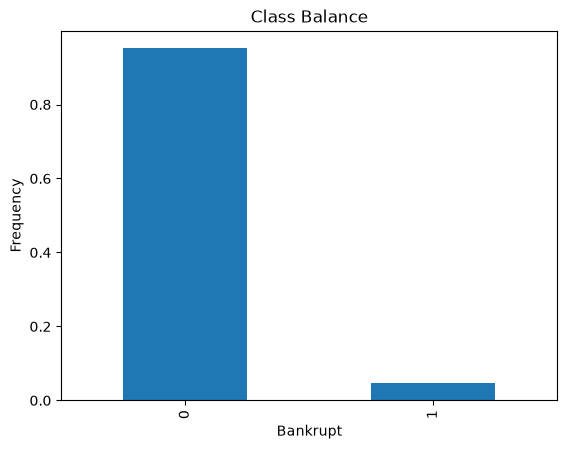

In [42]:
df["Class"].value_counts(normalize=True).plot(
    kind="bar",
    xlabel="Bankrupt",
    ylabel="Frequency",
    title="Class Balance"
);
plt.savefig("../reports/figures/class_balance.png", dpi=150)

## Class Distribution Analysis

From the visualization above, we can observe that the dataset has a significant imbalance between the positive and negative classes. The number of non-bankrupt companies is much higher than the number of bankrupt companies.

This class imbalance is an important factor to consider when evaluating the performance of classification models. Using **accuracy** alone may not provide a reliable measure, as a model could achieve a high accuracy by simply predicting the majority class while failing to identify bankrupt companies.

Therefore, evaluation metrics that focus on the performance of each class are more suitable for this problem. Metrics such as **precision**, **recall**, **F1-score**, and the **ROC-AUC score** will provide a better understanding of the model's ability to correctly identify bankrupt companies while minimizing false predictions.


## Feature Analysis

Feature **X27 (Profit on operating activities / Financial expenses)** measures the company's ability to cover financial expenses using operating profits. This feature may indicate financial stability, where higher values could suggest lower bankruptcy risk.


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43405 entries, 0 to 43404
Data columns (total 66 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    43405 non-null  int64  
 1   X1      43397 non-null  float64
 2   X2      43397 non-null  float64
 3   X3      43397 non-null  float64
 4   X4      43271 non-null  float64
 5   X5      43316 non-null  float64
 6   X6      43397 non-null  float64
 7   X7      43397 non-null  float64
 8   X8      43311 non-null  float64
 9   X9      43396 non-null  float64
 10  X10     43397 non-null  float64
 11  X11     43361 non-null  float64
 12  X12     43271 non-null  float64
 13  X13     43278 non-null  float64
 14  X14     43397 non-null  float64
 15  X15     43369 non-null  float64
 16  X16     43310 non-null  float64
 17  X17     43311 non-null  float64
 18  X18     43397 non-null  float64
 19  X19     43277 non-null  float64
 20  X20     43278 non-null  float64
 21  X21     37551 non-null  float64
 22  X22     4

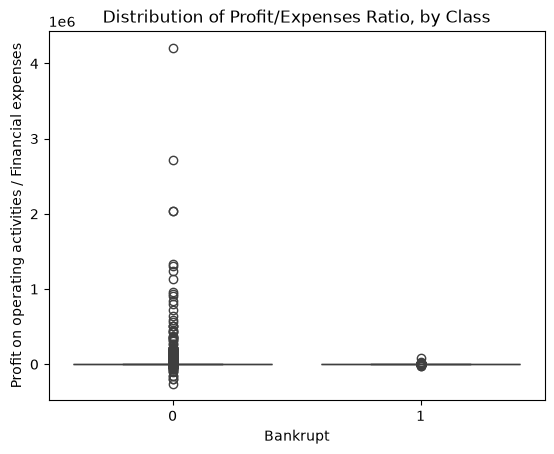

In [44]:
sns.boxplot(x="Class", y="X27",data=df);
plt.xlabel("Bankrupt")
plt.ylabel("Profit on operating activities / Financial expenses")
plt.title("Distribution of Profit/Expenses Ratio, by Class");

In [67]:
df["X27"].describe().apply("{0:,.0f}".format)

count       40,641
mean         1,108
std         35,015
min       -259,000
25%              0
50%              1
75%              5
max      4,210,000
Name: X27, dtype: str

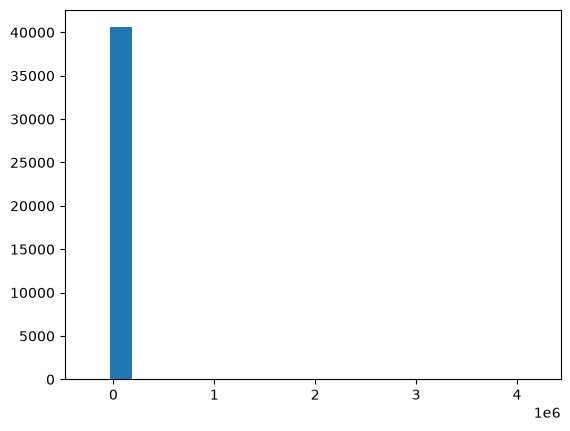

In [75]:
plt.hist(df["X27"], bins=20);